In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
print("Libraries loaded ✅")

Libraries loaded ✅


In [12]:
df = pd.read_csv("../Data/telco_churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Duplicates ===")
print(df.duplicated().sum())

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

In [14]:
# Fix TotalCharges column (contains spaces)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop rows with missing values (only 11 rows)
df.dropna(inplace=True)

# Convert Churn to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop customerID (not useful for modelling)
df.drop(columns=["customerID"], inplace=True)

print(f"Clean dataset shape: {df.shape}")
df.head()

Clean dataset shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


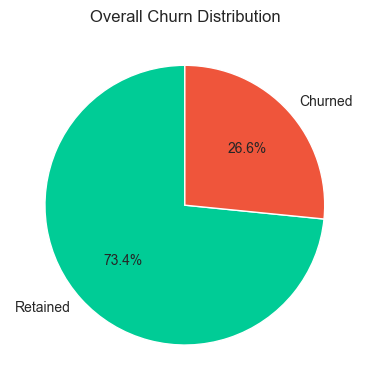

Churn Rate: 26.58%


In [15]:
churn_counts = df["Churn"].value_counts()
labels = ["Retained", "Churned"]

plt.figure(figsize=(6, 4))
plt.pie(churn_counts, labels=labels, autopct="%1.1f%%",
        colors=["#00CC96", "#EF553B"], startangle=90)
plt.title("Overall Churn Distribution")
plt.tight_layout()
plt.savefig("../churn_distribution.png", dpi=150)
plt.show()

print(f"Churn Rate: {df['Churn'].mean()*100:.2f}%")

C:\Users\USER\AppData\Local\Temp\ipykernel_3088\3001246479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x="Contract", y="Churn",


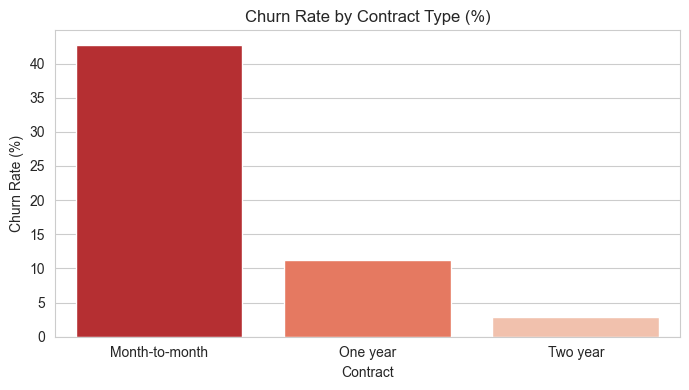

In [16]:
contract_churn = df.groupby("Contract")["Churn"].mean().reset_index()
contract_churn["Churn"] = (contract_churn["Churn"] * 100).round(2)

plt.figure(figsize=(7, 4))
sns.barplot(data=contract_churn, x="Contract", y="Churn",
            palette="Reds_r")
plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("../churn_by_contract.png", dpi=150)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_3088\1723225761.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_churn, x="TenureGroup", y="Churn",


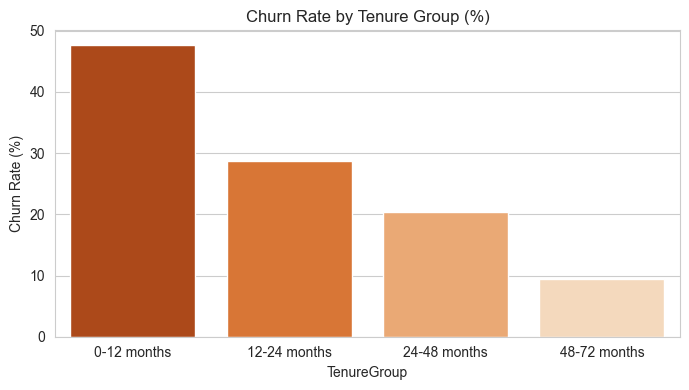

In [17]:
df["TenureGroup"] = pd.cut(df["tenure"],
                            bins=[0, 12, 24, 48, 72],
                            labels=["0-12 months", "12-24 months",
                                    "24-48 months", "48-72 months"])

tenure_churn = df.groupby("TenureGroup")["Churn"].mean().reset_index()
tenure_churn["Churn"] = (tenure_churn["Churn"] * 100).round(2)

plt.figure(figsize=(7, 4))
sns.barplot(data=tenure_churn, x="TenureGroup", y="Churn",
            palette="Oranges_r")
plt.title("Churn Rate by Tenure Group (%)")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("../churn_by_tenure.png", dpi=150)
plt.show()

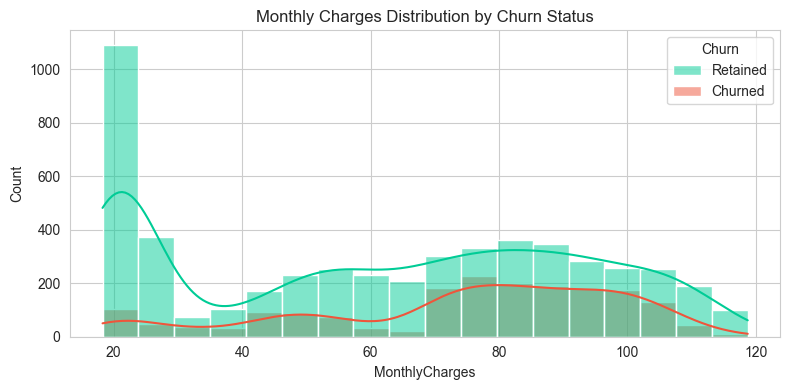

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="MonthlyCharges",
             hue=df["Churn"].map({1: "Churned", 0: "Retained"}),
             kde=True, palette=["#00CC96", "#EF553B"])
plt.title("Monthly Charges Distribution by Churn Status")
plt.tight_layout()
plt.savefig("../monthly_charges.png", dpi=150)
plt.show()

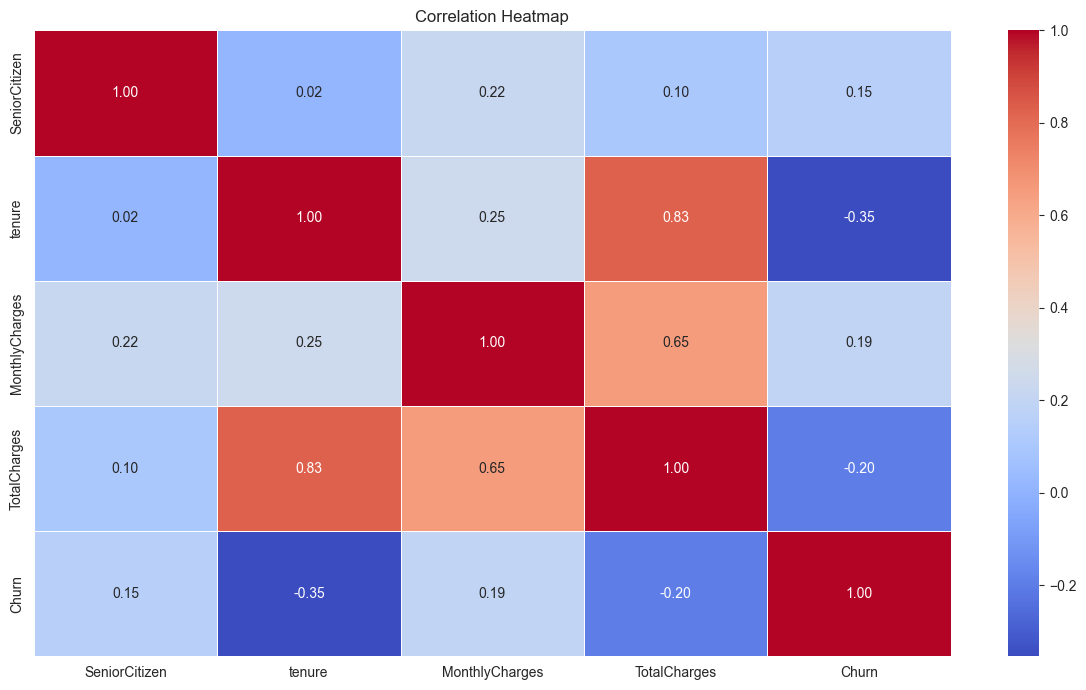

In [19]:
numeric_df = df.select_dtypes(include="number").drop(
    columns=["TenureGroup"], errors="ignore")

plt.figure(figsize=(12, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../correlation_heatmap.png", dpi=150)
plt.show()

## 📋 Key EDA Findings

1. **Overall churn rate is ~26%** — roughly 1 in 4 customers leave
2. **Month-to-month customers churn the most** (~43%) vs two-year contracts (~3%)
3. **New customers (0–12 months) are the highest risk** — churn drops significantly after 2 years
4. **Higher monthly charges correlate strongly with churn** — pricing is a key driver
5. **Customers without partners or dependents churn more** — less personal attachment to the service